<a href="https://colab.research.google.com/github/KiranmayiBandaru/credit-scoring-loan-risk-analysis/blob/main/credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Exploratory Data Analysis  -  EDA

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/KiranmayiBandaru/credit-scoring-loan-risk-analysis/refs/heads/main/customer_dataset.csv')
print(df.shape) #tuples and columns

print(df.head())


(5451, 13)
   id  person_age  person_income person_home_ownership  person_emp_length  \
0   0          37          35000                  RENT                0.0   
1   1          22          56000                   OWN                6.0   
2   2          29          28800                   OWN                8.0   
3   3          30          70000                  RENT               14.0   
4   4          22          60000                  RENT                2.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0   EDUCATION          B       6000          11.49                 0.17   
1     MEDICAL          C       4000          13.35                 0.07   
2    PERSONAL          A       6000           8.90                 0.21   
3     VENTURE          B      12000          11.11                 0.17   
4     MEDICAL          A       6000           6.92                 0.10   

  cb_person_default_on_file  cb_person_cred_hist_length  loan_status  
0   

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          5451 non-null   int64  
 1   person_age                  5451 non-null   int64  
 2   person_income               5451 non-null   int64  
 3   person_home_ownership       5451 non-null   object 
 4   person_emp_length           5451 non-null   float64
 5   loan_intent                 5451 non-null   object 
 6   loan_grade                  5451 non-null   object 
 7   loan_amnt                   5451 non-null   int64  
 8   loan_int_rate               5451 non-null   float64
 9   loan_percent_income         5451 non-null   float64
 10  cb_person_default_on_file   5451 non-null   object 
 11  cb_person_cred_hist_length  5451 non-null   int64  
 12  loan_status                 5451 non-null   int64  
dtypes: float64(3), int64(6), object(4

In [7]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,5451.00000,5451.000000,5.451000e+03,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000
mean,2725.00000,27.476977,6.453183e+04,4.667584,9254.338653,10.669551,0.158191,5.750504,0.146395
std,1573.71249,5.864273,3.669211e+04,3.889993,5600.892743,3.052436,0.091173,3.949560,0.353534
min,0.00000,21.000000,9.600000e+03,0.000000,1000.000000,5.420000,0.010000,2.000000,0.000000
25%,1362.50000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,2725.00000,26.000000,6.000000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,4087.50000,30.000000,7.800000e+04,7.000000,12000.000000,12.890000,0.210000,8.000000,0.000000
max,5450.00000,84.000000,1.200000e+06,26.000000,35000.000000,22.110000,0.510000,30.000000,1.000000


Here we can see unsual or interesting values :
  
for example , when the max age_of_customer = 144.
mean vs meadian is 50% , if they are different they are skewed.
large range — if min is 0 and max is 6000000, that's a huge range which affects your model.


person_age has a min of 21 and max of 84. That seems reasonable.
But look at person_income — min is 9,600 and max is 1,200,000. That's a huge range. Someone earning 9,600 vs someone earning 12,00,000 — that's extreme.
Also look at person_emp_length — min is 0 and max is 26 years. Someone with 0 years employment applying for a loan is unusual.
These are called outliers — extreme values that can confuse your model.


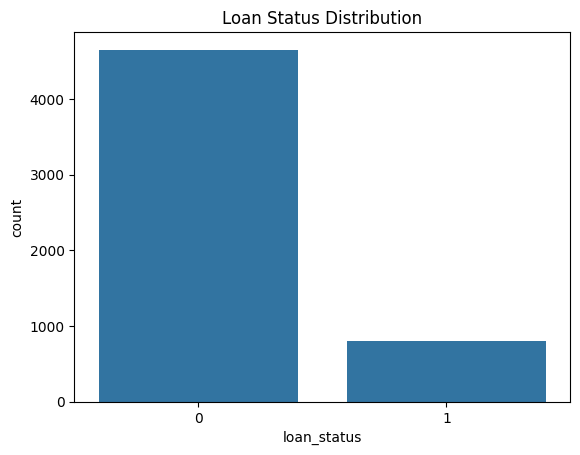

In [8]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

Here, count of the non-defaulters is extremely higher than the defaulters , hence it gets difficult for the algorithm to identify features of the defaulters class.

Hence , we see "class imbalance".


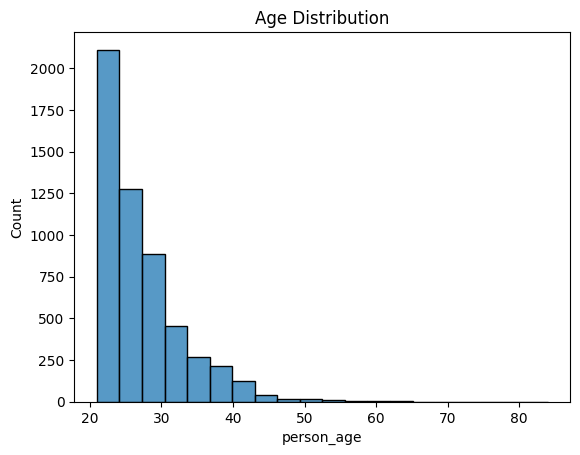

In [9]:
sns.histplot(df['person_age'] , bins=20)
plt.title('Age Distribution')
plt.show()

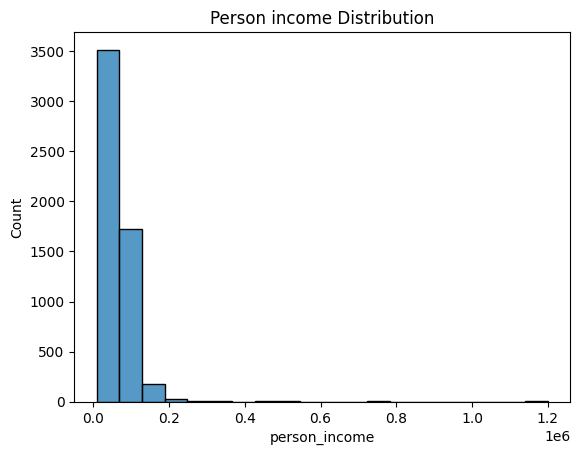

In [11]:
sns.histplot(df['person_income'], bins=20)
plt.title('Person income Distribution')
plt.show()

That's called a right skewed distribution — most people have low income but a few people have very high income (remember that max of 12,00,000 we saw earlier). Those few high income people create that long tail on the right.

This is an outlier problem.

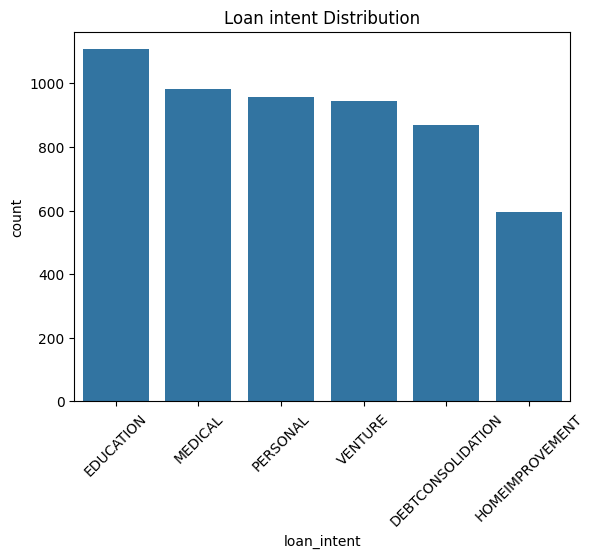

In [12]:
sns.countplot(x='loan_intent', data=df)
plt.xticks(rotation=45)
plt.title('Loan intent Distribution')
plt.show()

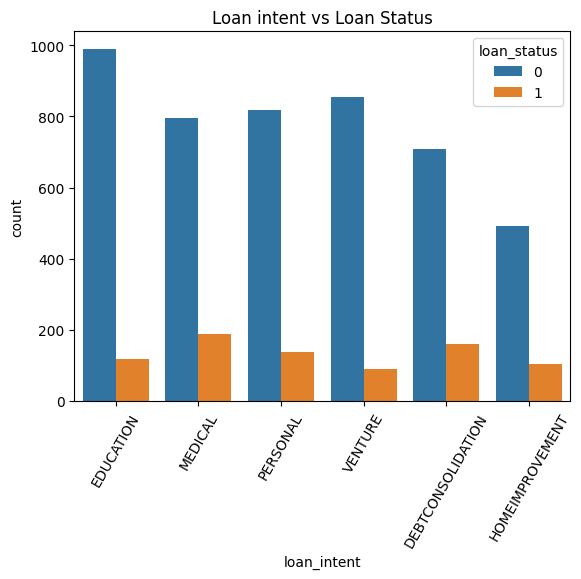

In [17]:
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.xticks(rotation = 60)
plt.title('Loan intent vs Loan Status')
plt.show()

no single loan intent is dramatically riskier than others. That's a valid EDA insight.

  -> No missing values

  -> 4 categorical columns need encoding

  -> Class imbalance confirmed — SMOTE needed

  -> Most applicants are aged 20-30

  -> Income is right skewed — outliers exist

  -> Loan intent fairly evenly distributed
  
  -> No single intent dramatically causes default

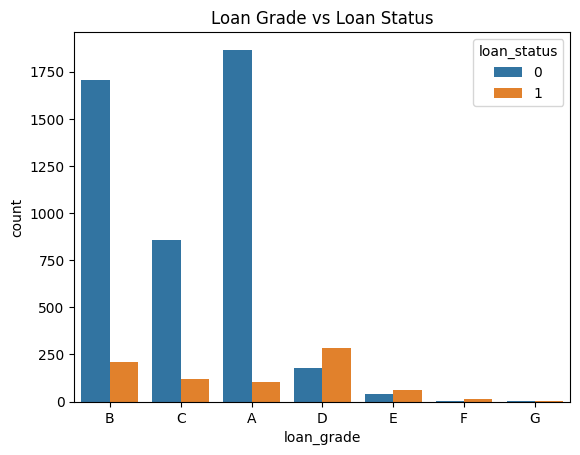

In [22]:
sns.countplot(x='loan_grade', hue="loan_status", data=df)
plt.xticks(rotation=0)
plt.title('Loan Grade vs Loan Status')
plt.show()

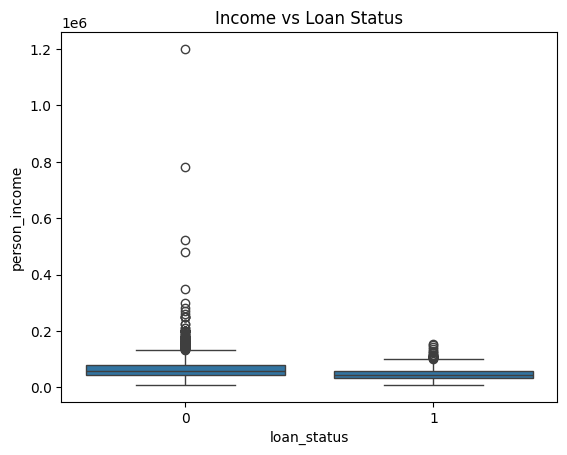

In [30]:
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Income vs Loan Status')
plt.show()

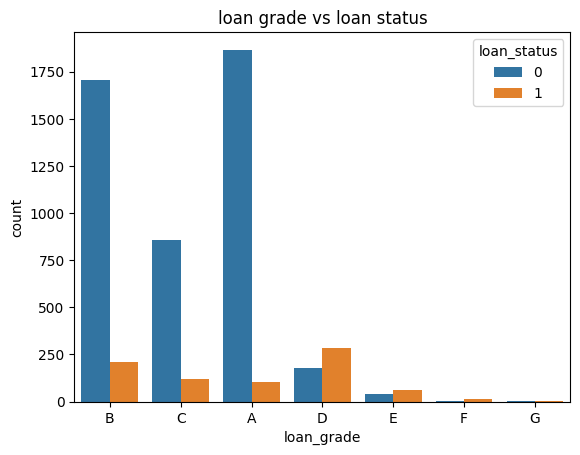

In [33]:
sns.countplot(x='loan_grade', hue='loan_status', data=df)
plt.title('loan grade vs loan status')
plt.show()

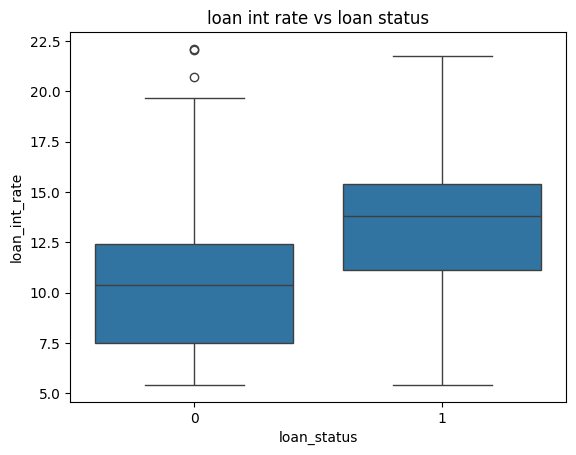

In [38]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)
plt.title('loan int rate vs loan status')
plt.show()

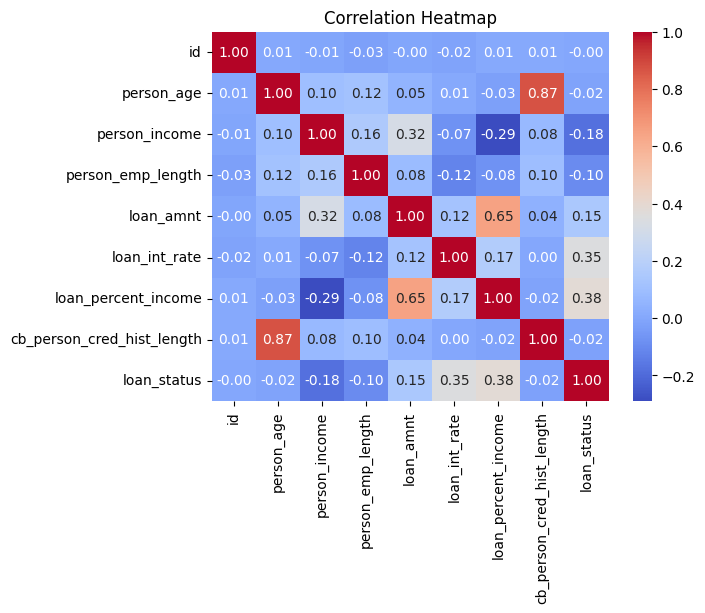

In [39]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()